In [1]:
import os
os.chdir("/Users/val/Library/CloudStorage/GoogleDrive-valentine.svensson@gmail.com/My Drive/Blog/250630 - Slot machine strategy/")

import polars as pl
import plotnine as p

from theme_nxn import theme_nxn, scale_color_nxn

In [16]:
# Read empirical balance curves from slot machine data
df_empirical = pl.read_csv("slot_machine_data.csv")
print(f"Loaded {len(df_empirical)} rows of empirical slot machine data")

# Filter out rows with null runId and convert to Int64
df_empirical = df_empirical.filter(pl.col("runId").is_not_null()).with_columns(pl.col("runId").cast(pl.Int64))
print(f"After filtering null runId: {len(df_empirical)} rows")
print(f"Unique episodes: {df_empirical['episodeId'].n_unique()}")

# Read simulated Q-learning agent data
df_simulated = pl.read_csv("simulated_slot_machine_data.csv")
print(f"\nLoaded {len(df_simulated)} rows of simulated Q-learning data")
print(f"Columns: {df_simulated.columns}")
print(f"Unique episodes: {df_simulated['episodeId'].n_unique()}")

# Read naive strategy data
df_naive = pl.read_csv("naive_slot_machine_data.csv")
print(f"\nLoaded {len(df_naive)} rows of naive strategy data")
print(f"Columns: {df_naive.columns}")
print(f"Unique episodes: {df_naive['episodeId'].n_unique()}")

# Read optimal strategy data
df_optimal = pl.read_csv("optimal_slot_machine_data.csv")
print(f"\nLoaded {len(df_optimal)} rows of optimal strategy data")
print(f"Columns: {df_optimal.columns}")
print(f"Unique episodes: {df_optimal['episodeId'].n_unique()}")

# Ensure all runId columns are Int64
df_simulated = df_simulated.with_columns(pl.col("runId").cast(pl.Int64))
df_naive = df_naive.with_columns(pl.col("runId").cast(pl.Int64))
df_optimal = df_optimal.with_columns(pl.col("runId").cast(pl.Int64))

# Add data source indicators
df_empirical = df_empirical.with_columns(pl.lit("Human").alias("data_source"))
df_simulated = df_simulated.with_columns(pl.lit("Q-Learning Agent").alias("data_source"))
df_naive = df_naive.with_columns(pl.lit("Cash out only").alias("data_source"))
df_optimal = df_optimal.with_columns(pl.lit("Optimal EV").alias("data_source"))

# Combine all four datasets
df = pl.concat([
    df_empirical.select(['episodeId', 'runId', 'timestamp', 'balance', 'data_source']),
    df_simulated.select(['episodeId', 'runId', 'timestamp', 'balance', 'data_source']),
    df_naive.select(['episodeId', 'runId', 'timestamp', 'balance', 'data_source']),
    df_optimal.select(['episodeId', 'runId', 'timestamp', 'balance', 'data_source'])
]
)
print(f"\nCombined dataset: {len(df)} rows")
print(f"Data sources: {df['data_source'].value_counts()}")

df.head()

Loaded 2426 rows of empirical slot machine data
After filtering null runId: 2324 rows
Unique episodes: 73

Loaded 3147 rows of simulated Q-learning data
Columns: ['decisionId', 'runId', 'episodeId', 'timestamp', 'action', 'actionDescription', 'respinsUsed', 'balance', 'currentPayout', 'totalCost', 'blank', 'coin', 'coinStack', 'snake', 'net', 'x2', 'clover', 'crown', 'reel0', 'reel1', 'reel2', 'reel3', 'validActions']
Unique episodes: 37

Loaded 10719 rows of naive strategy data
Columns: ['decisionId', 'runId', 'episodeId', 'timestamp', 'action', 'actionDescription', 'respinsUsed', 'balance', 'currentPayout', 'totalCost', 'blank', 'coin', 'coinStack', 'snake', 'net', 'x2', 'clover', 'crown', 'reel0', 'reel1', 'reel2', 'reel3', 'validActions']
Unique episodes: 500

Loaded 9644 rows of optimal strategy data
Columns: ['decisionId', 'runId', 'episodeId', 'timestamp', 'action', 'actionDescription', 'respinsUsed', 'balance', 'currentPayout', 'totalCost', 'blank', 'coin', 'coinStack', 'snake'

episodeId,runId,timestamp,balance,data_source
i64,i64,i64,i64,str
1,1,1751601680931,98,"""Human"""
2,1,1751601754385,101,"""Human"""
2,1,1751601757048,100,"""Human"""
2,1,1751601759340,99,"""Human"""
3,1,1751601764601,95,"""Human"""


In [17]:
# Set custom order for data_source categories
desired_order = ["Human", "Q-Learning Agent", "Cash out only", "Optimal EV"]

# Group by 'data_source', 'episodeId' and 'runId', get the last balance for each group
final_balances = (
  df.sort(['data_source', "timestamp"])
    .group_by(["data_source", "episodeId", "runId"])
    .agg(pl.col("balance").max())
    .with_columns(
      (pl.col("data_source") + "_" + pl.col("runId").cast(pl.Utf8)).alias("source_run_id")
    )
    .with_columns(
        pl.col("data_source").cast(pl.Enum(desired_order))
    )
)

final_balances

data_source,episodeId,runId,balance,source_run_id
enum,i64,i64,i64,str
"""Cash out only""",29,23,90,"""Cash out only_23"""
"""Cash out only""",243,2,43,"""Cash out only_2"""
"""Optimal EV""",128,24,76,"""Optimal EV_24"""
"""Cash out only""",423,14,32,"""Cash out only_14"""
"""Cash out only""",440,18,9,"""Cash out only_18"""
…,…,…,…,…
"""Cash out only""",203,14,70,"""Cash out only_14"""
"""Optimal EV""",256,6,43,"""Optimal EV_6"""
"""Optimal EV""",106,12,80,"""Optimal EV_12"""


/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 4 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: 250705.human.q.balance.png


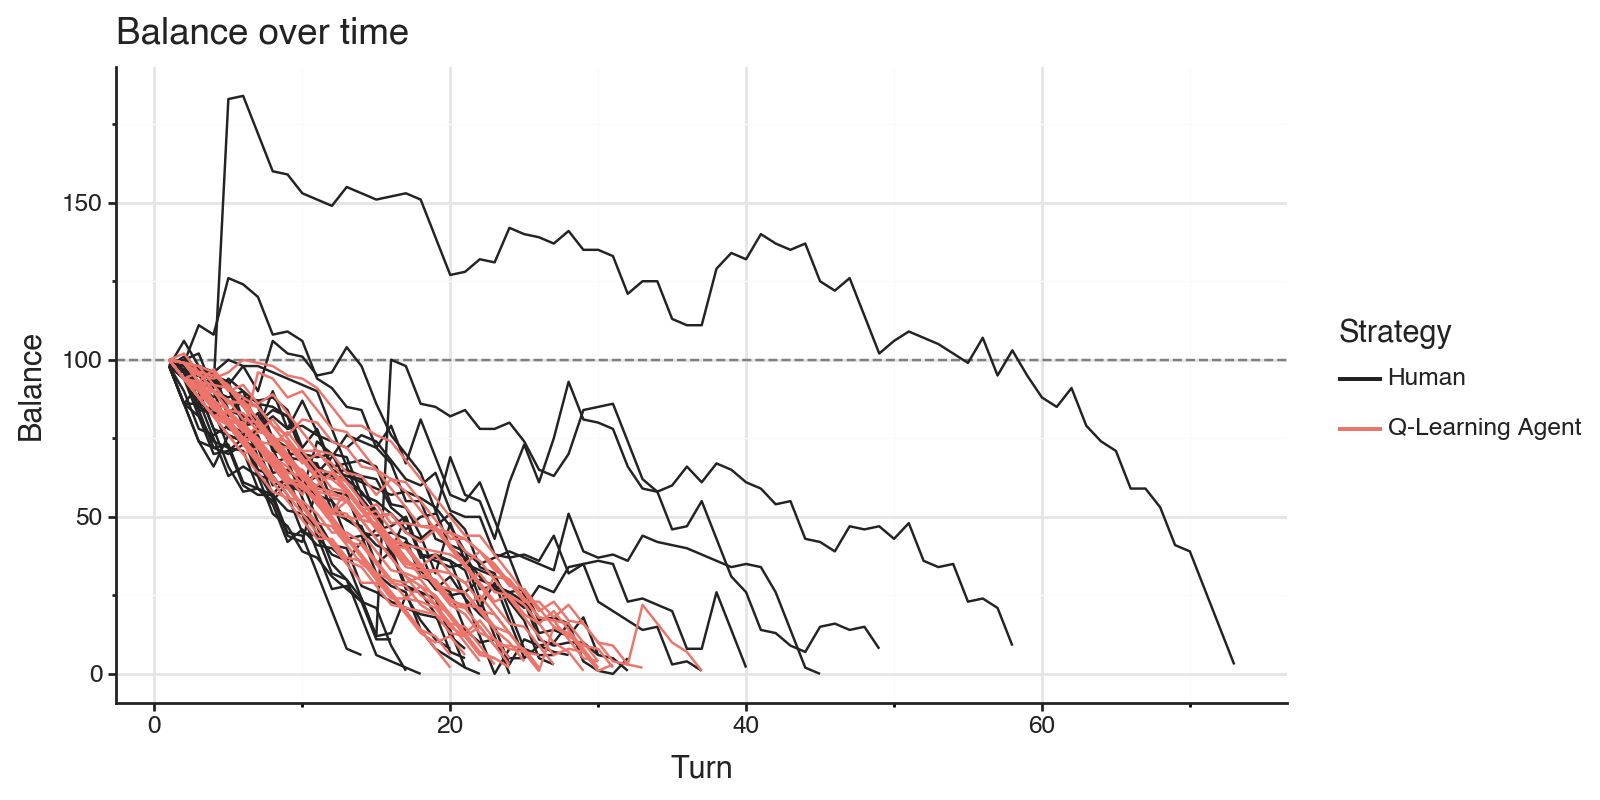

In [18]:
# Filter data first, then recreate enum with only present categories
filtered_data = (
    final_balances
    .filter(pl.col("data_source") != "Cash out only")
    .filter(pl.col("data_source") != "Optimal EV")
)

# Get the categories that are actually present in filtered data
present_categories = filtered_data["data_source"].unique().to_list()
# Maintain the original order by filtering the desired_order list
ordered_present_categories = [cat for cat in desired_order if cat in present_categories]

# Recreate the enum with only present categories
filtered_data = filtered_data.with_columns(
    pl.col("data_source").cast(pl.Enum(ordered_present_categories))
)

p_ = (
    p.ggplot(filtered_data)
    + p.aes(x="episodeId", y="balance", color="data_source", group='source_run_id')
    + p.geom_hline(yintercept=100, linetype='dashed', color='gray')
    + p.geom_line()
    + scale_color_nxn()
    + theme_nxn()
    + p.theme(figure_size=(8, 4))
    + p.labs(
        title='Balance over time',
        x='Turn',
        y='Balance',
        color='Strategy',
    )
)

p_.save("250705.human.q.balance.png", dpi=300, width=8, height=4)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 4 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: 250705.human.q.naive.balance.png


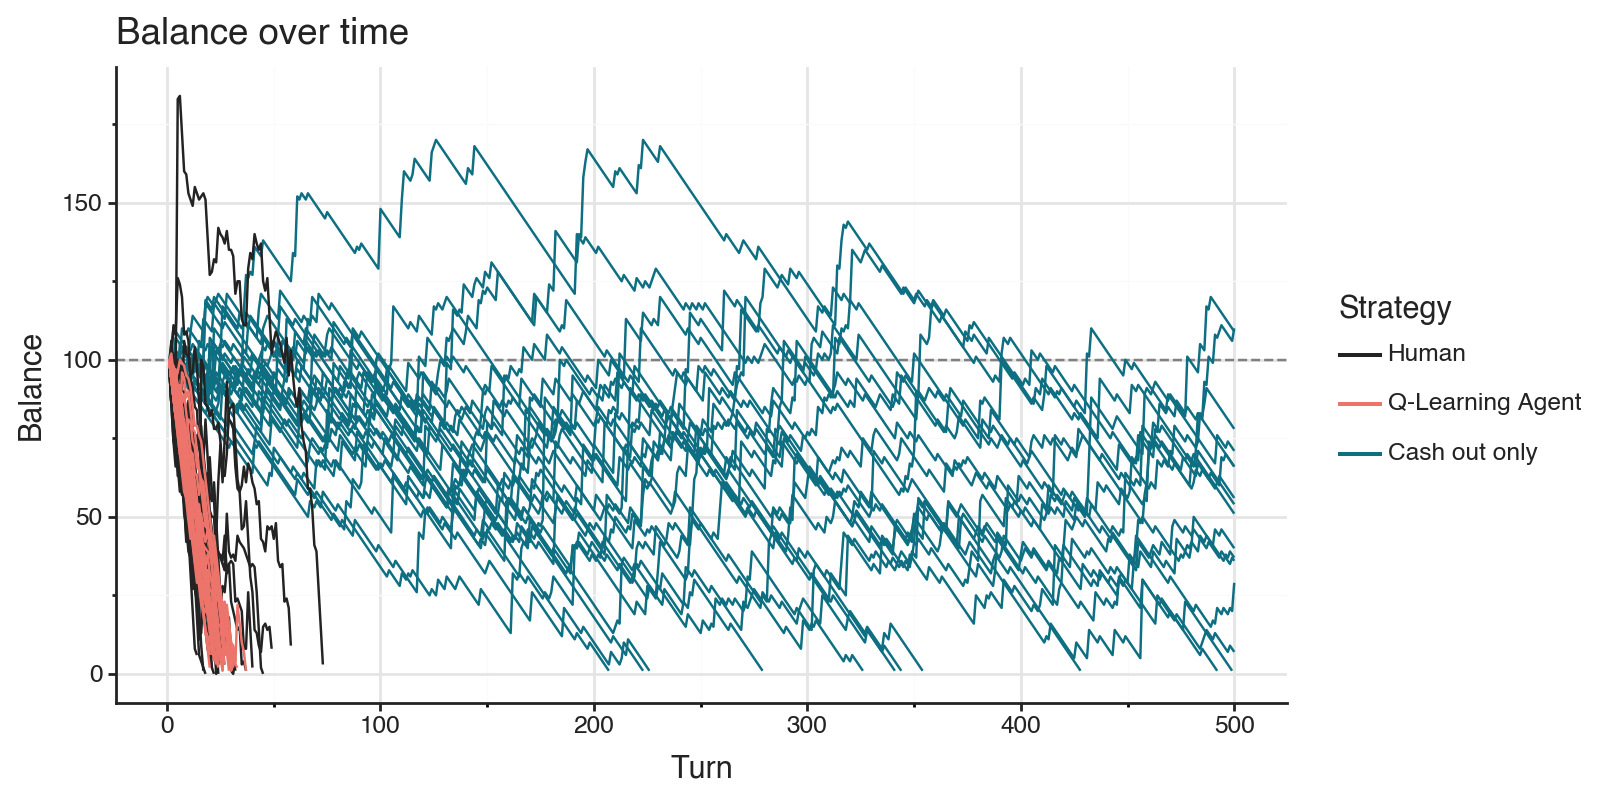

In [23]:
# Filter data first, then recreate enum with only present categories
filtered_data2 = (
    final_balances
    .filter(pl.col("data_source") != "Optimal EV")
)

# Get the categories that are actually present in filtered data
present_categories2 = filtered_data2["data_source"].unique().to_list()
# Maintain the original order by filtering the desired_order list
ordered_present_categories2 = [cat for cat in desired_order if cat in present_categories2]

# Recreate the enum with only present categories
filtered_data2 = filtered_data2.with_columns(
    pl.col("data_source").cast(pl.Enum(ordered_present_categories2))
)

p_ = (
    p.ggplot(filtered_data2)
    + p.aes(x="episodeId", y="balance", color="data_source", group='source_run_id')
    + p.geom_hline(yintercept=100, linetype='dashed', color='gray')
    + p.geom_line()
    + scale_color_nxn()
    + theme_nxn()
    + p.theme(figure_size=(8, 4))
    + p.labs(
        title='Balance over time',
        x='Turn',
        y='Balance',
        color='Strategy',
    )
)

p_.save("250705.human.q.naive.balance.png", dpi=300, width=8, height=4)

p_

/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 4 in image.
/Users/val/miniforge3/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: 250705.human.q.naive.optimal.balance.png


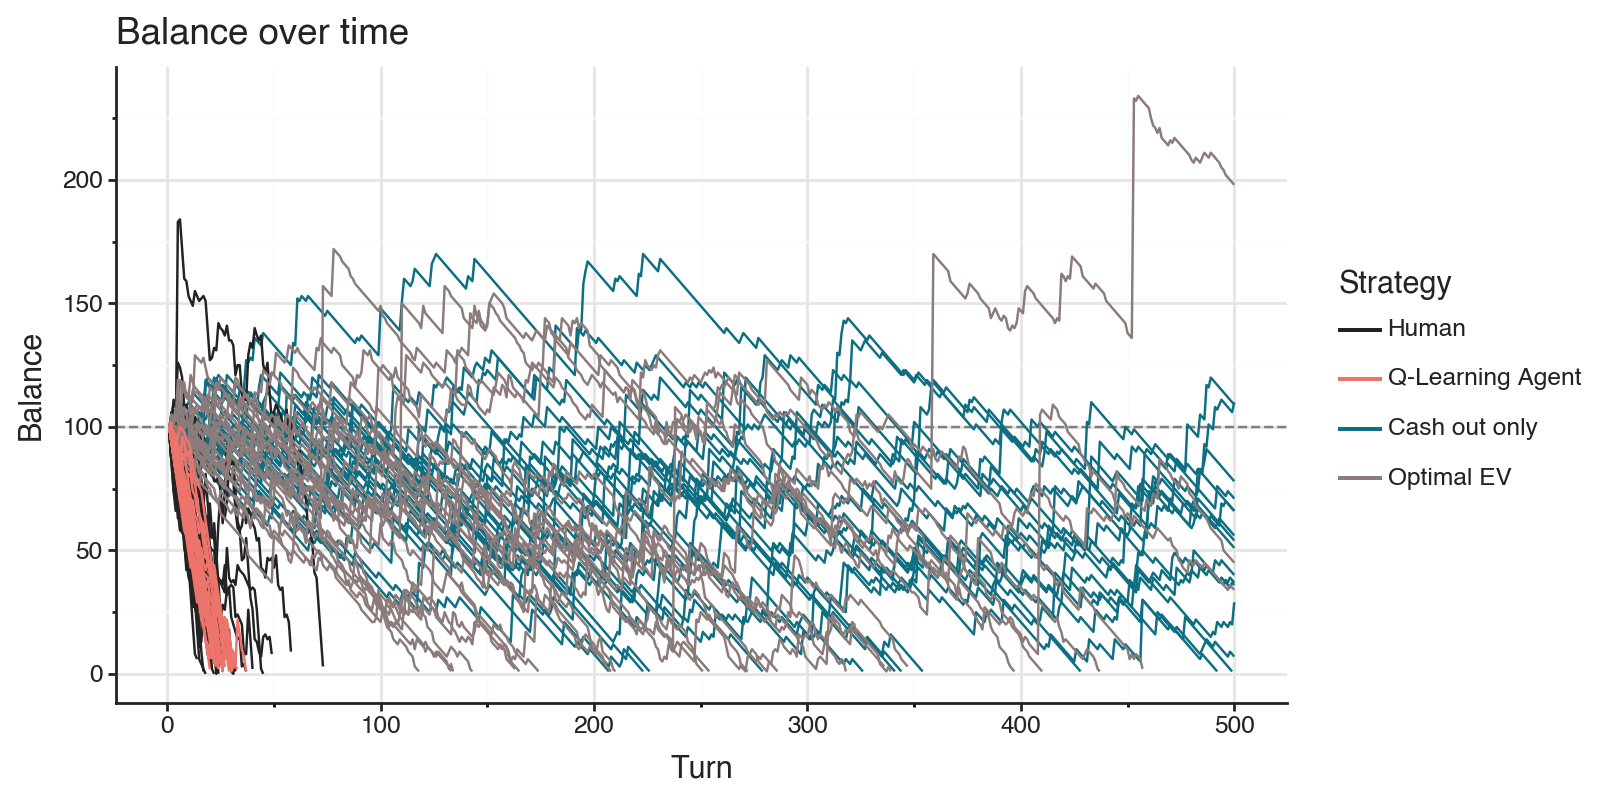

In [22]:
# Filter data first, then recreate enum with only present categories
filtered_data2 = (
    final_balances
)

# Get the categories that are actually present in filtered data
present_categories2 = filtered_data2["data_source"].unique().to_list()
# Maintain the original order by filtering the desired_order list
ordered_present_categories2 = [cat for cat in desired_order if cat in present_categories2]

# Recreate the enum with only present categories
filtered_data2 = filtered_data2.with_columns(
    pl.col("data_source").cast(pl.Enum(ordered_present_categories2))
)

p_ = (
    p.ggplot(filtered_data2)
    + p.aes(x="episodeId", y="balance", color="data_source", group='source_run_id')
    + p.geom_hline(yintercept=100, linetype='dashed', color='gray')
    + p.geom_line()
    + scale_color_nxn()
    + theme_nxn()
    + p.theme(figure_size=(8, 4))
    + p.labs(
        title='Balance over time',
        x='Turn',
        y='Balance',
        color='Strategy',
    )
)

p_.save("250705.human.q.naive.optimal.balance.png", dpi=300, width=8, height=4)

p_